In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("college_student_placement_dataset.csv")
df

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...,...
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [4]:
X=df[['CGPA','IQ']]
X

,CGPA,IQ
0,6.28,107
1,5.37,97
2,5.83,109
3,5.75,122
4,7.69,96
...,...,...
9995,8.29,119
9996,9.34,70
9997,6.25,89
9998,8.92,107


In [7]:
df['Placement']=df['Placement'].replace({
    "No":0,
    "Yes":1
})


C:\Users\Santec.DESKTOP-DO8P42R\AppData\Local\Temp\ipykernel_8872\2516982125.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Placement']=df['Placement'].replace({


In [8]:
df['Placement'].value_counts()

Placement
0    8341
1    1659
Name: count, dtype: int64

In [9]:
Y=df['Placement']
Y

0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    0
9997    0
9998    0
9999    0
Name: Placement, Length: 10000, dtype: int64

perform EDA

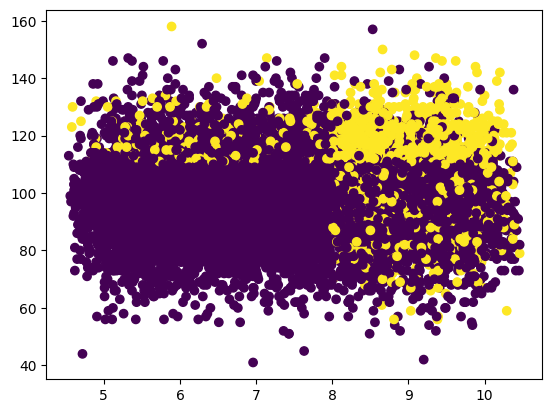

In [10]:
plt.scatter(df['CGPA'],df['IQ'],c=df['Placement'])

#  split the training data and testing data 

In [38]:
from sklearn.model_selection import train_test_split

x_trian,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)


In [39]:
x_trian

,CGPA,IQ
5435,5.44,90
952,7.73,81
6047,8.19,122
6804,5.19,87
6765,7.66,106
...,...,...
9089,8.81,91
5585,6.95,89
4195,6.66,92
6822,10.01,86


In [40]:
x_test

,CGPA,IQ
6930,8.89,88
7811,6.90,97
5812,6.54,103
7667,6.55,92
203,9.52,115
...,...,...
1805,8.99,76
3478,8.68,117
5405,9.34,100
7927,5.89,102


In [41]:
y_train

5435    0
952     0
6047    1
6804    0
6765    0
       ..
9089    0
5585    0
4195    0
6822    0
6742    0
Name: Placement, Length: 8000, dtype: int64

# preprocessing to scal the vlaue between 0 and 1

In [42]:
# create a object of standardscalar
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

In [43]:
#  first scale the value of X
x_trian=scalar.fit_transform(x_trian)
x_trian

array([[-1.42002966, -0.62958841],
       [ 0.13734105, -1.22409281],
       [ 0.45017535,  1.48420499],
       ...,
       [-0.59033871, -0.49747632],
       [ 1.68791102, -0.89381259],
       [-0.12788802, -1.55437303]])

In [44]:
#  scale the value of X in the testing data
x_test=scalar.fit_transform(x_test)
x_test

array([[ 0.91270299, -0.76427025],
       [-0.44242062, -0.15201049],
       [-0.68756861,  0.25616268],
       ...,
       [ 1.21913798,  0.05207609],
       [-1.13019693,  0.18813382],
       [-0.0406503 ,  1.07250903]])

# trian the model

In [45]:
from sklearn.linear_model import LogisticRegression

clf=LogisticRegression()


In [46]:
clf.fit(x_trian,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
y_pred=clf.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [48]:
y_test

6930    0
7811    0
5812    0
7667    0
203     1
       ..
1805    0
3478    1
5405    0
7927    0
883     0
Name: Placement, Length: 2000, dtype: int64

# evaluate the trained mode "calcualte the accuracy of the model"

In [51]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.859

In [53]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_pred,y_test)

array([[1630,  217],
       [  65,   88]])

# convert the model into file using pickl

In [61]:
import pickle
pickle.dump(clf,open("models.pkl","wb"))

In [62]:
pickle.dump(scalar,open("scalar.pkl","wb"))

In [60]:
clf.predict([[1,20]])
clf.predict(scalar.transform([[6,90]]))

C:\Users\Santec.DESKTOP-DO8P42R\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [56]:
df['Placement'].value_counts()

Placement
0    8341
1    1659
Name: count, dtype: int64

In [57]:
np.unique(y_pred,return_counts=True)

(array([0, 1]), array([1847,  153]))

In [58]:
df.groupby("Placement")[["CGPA","IQ"]].mean()

,CGPA,IQ
Placement,,
0,7.321527,97.552452
1,8.592483,109.121760
